In [112]:

# import libraries

# 1. to handle the data
import pandas as pd
import numpy as np

# to visualize the dataset
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# To preprocess the data
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer
# import iterative imputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# machine learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
#for classification tasks
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, RandomForestRegressor
from xgboost import XGBClassifier
#metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_absolute_error, mean_squared_error, r2_score

# ignore warnings   
import warnings
warnings.filterwarnings('ignore')

### Load the dataset

In [113]:
# load the dataset
data = pd.read_csv('heart_disease_uci.csv')

# print the first 5 rows of the dataset
data.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Exploratory Data Analysis (EDA)

### Explore each Column

In [114]:
# exploring the datatype of each column
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [115]:
# data shape
data.shape

(920, 16)

In [116]:
# id column
data['id'].min() , data['id'].max()

(1, 920)

In [117]:
# age column
data['age'].min() , data['age'].max()

(28, 77)

In [118]:
# let's summarize the age column
data['age'].describe()

count    920.000000
mean      53.510870
std        9.424685
min       28.000000
25%       47.000000
50%       54.000000
75%       60.000000
max       77.000000
Name: age, dtype: float64

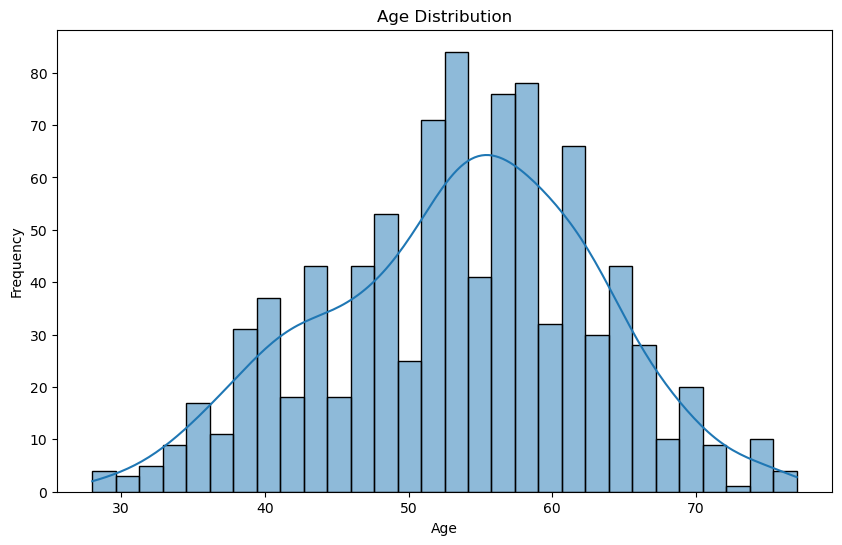

In [119]:
# draw a histogram of age column
plt.figure(figsize=(10,6))
sns.histplot(data['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


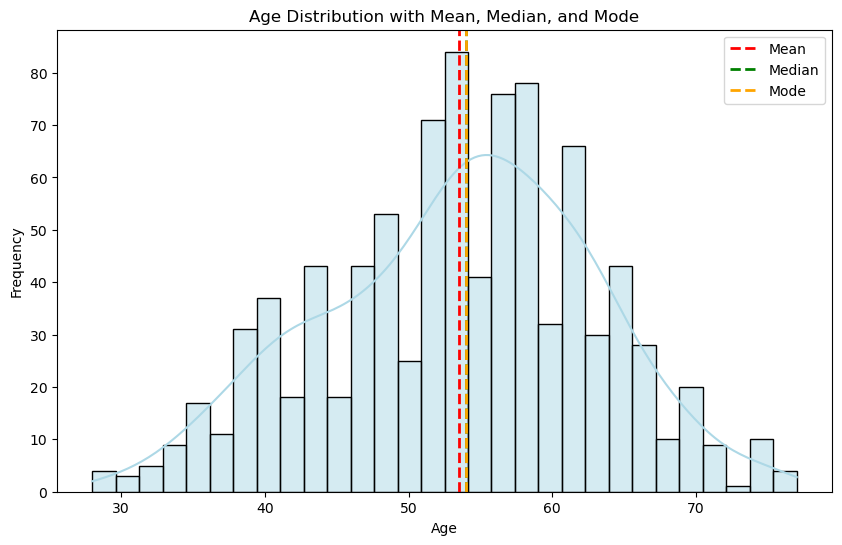

(np.float64(53.51086956521739), 54.0, np.int64(54))

In [120]:
# plot the mean , median , mode of age column
mean_age = data['age'].mean()
median_age = data['age'].median()
mode_age = data['age'].mode()[0]
plt.figure(figsize=(10,6))
sns.histplot(data['age'], bins=30, kde=True, color='lightblue')
plt.axvline(mean_age, color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.axvline(median_age, color='green', linestyle='dashed', linewidth=2, label='Median')
plt.axvline(mode_age, color='orange', linestyle='dashed', linewidth=2, label='Mode')
plt.title('Age Distribution with Mean, Median, and Mode')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# print the value of mean , median , mode
mean_age, median_age, mode_age


In [121]:
# plot the histogram of age column using plotly and coloring this by sex
fig = px.histogram(data, x='age', color='sex', nbins=30, title='Age Distribution by Sex')
fig.update_layout(xaxis_title='Age', yaxis_title='Count')
fig.show()

In [122]:
# find the values of sex column
data['sex'].value_counts()

sex
Male      726
Female    194
Name: count, dtype: int64

In [123]:
# calculate the percentage of each sex
data['sex'].value_counts(normalize=True) * 100  


sex
Male      78.913043
Female    21.086957
Name: proportion, dtype: float64

In [124]:
# calculate how more then male are there in comparison to female
male_count = data['sex'].value_counts()[1]
female_count = data['sex'].value_counts()[0]
difference = male_count - female_count
difference

np.int64(-532)

In [125]:
# find the values count of age column grouping by sex column
data.groupby('sex')['age'].value_counts()

sex     age
Female  54     15
        51     11
        62     10
        43      9
        48      9
               ..
Male    77      2
        28      1
        31      1
        33      1
        76      1
Name: count, Length: 91, dtype: int64

In [126]:
# lets deal with dataset column
# find the unique values of dataset column
data['dataset'].unique()

array(['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach'],
      dtype=object)

In [127]:
# find the unique values count in dataset column
data['dataset'].value_counts()

dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

<Axes: xlabel='dataset', ylabel='count'>

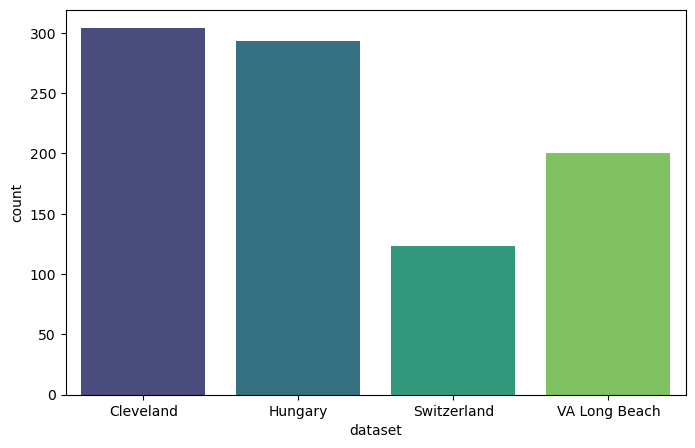

In [128]:
# plot the countplot of dataset column using seaborn
plt.figure(figsize=(8,5))
sns.countplot(x='dataset', data=data, palette='viridis')


In [129]:
# better plots using plotly
fig = px.histogram(data, x='dataset', color='dataset', title='Dataset Distribution', barmode='group')
fig.update_layout(xaxis_title='Dataset', yaxis_title='Count')
fig.show()

In [130]:
# print the values count of dataset column grouping by sex 
data.groupby('sex')['dataset'].value_counts()

sex     dataset      
Female  Cleveland         97
        Hungary           81
        Switzerland       10
        VA Long Beach      6
Male    Hungary          212
        Cleveland        207
        VA Long Beach    194
        Switzerland      113
Name: count, dtype: int64

In [131]:
# make a plot of age column using plotly and coloring this by dataset column
fig = px.histogram(data, x='age', color='dataset', nbins=30, title='Age Distribution by Dataset')
fig.update_layout(xaxis_title='Age', yaxis_title='Count')
fig.show()

In [132]:
# print the mean median and mode of age column grouping by dataset column
data.groupby('dataset')['age'].agg(['mean', 'median', lambda x: x.mode()[0]]).rename(columns={'<lambda_0>': 'mode'})


,mean,median,mode
dataset,,,
Cleveland,54.351974,55.5,58
Hungary,47.894198,49.0,54
Switzerland,55.317073,56.0,61
VA Long Beach,59.350000,60.0,62


### Let's explore cp (Chest Pain) column:

In [133]:
# values counts of cp column
data['cp'].value_counts()

cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

<Axes: xlabel='cp', ylabel='count'>

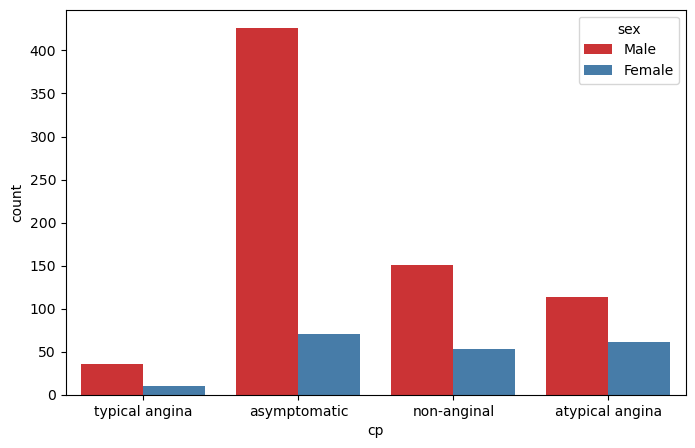

In [134]:
# countplot of cp column by sex
plt.figure(figsize=(8,5))
sns.countplot(x='cp', hue='sex', data=data, palette='Set1')
 

<Axes: xlabel='cp', ylabel='count'>

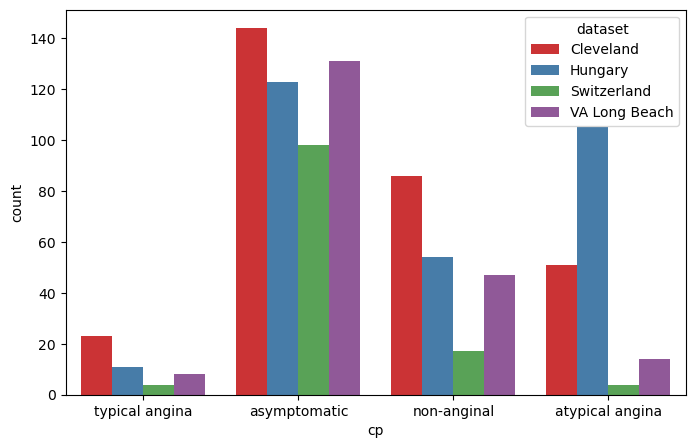

In [135]:
# count plot of cp column by dataset
plt.figure(figsize=(8,5))
sns.countplot(x='cp', hue='dataset', data=data, palette='Set1')

In [136]:

# draw the plot of age column grouped by cp column using plotly
fig = px.histogram(data, x='age', color='cp', nbins=30, title='Age Distribution by Chest Pain Type')
fig.update_layout(xaxis_title='Age', yaxis_title='Count')
fig.show()

### Let'e explore the trestbps (resting blood pressure) column:
The normal resting blood pressure is 120/80 mm Hg.

Write here, what will happen if the blood pressure is high or low and then you can bin the data based on those values.

In [137]:
# fitn the value counts of trestbps column
data['trestbps'].value_counts()

trestbps
120.0    131
130.0    115
140.0    102
110.0     59
150.0     56
        ... 
164.0      1
101.0      1
174.0      1
192.0      1
127.0      1
Name: count, Length: 61, dtype: int64

In [138]:
# describe the trestbps column
data['trestbps'].describe()

count    861.000000
mean     132.132404
std       19.066070
min        0.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: trestbps, dtype: float64

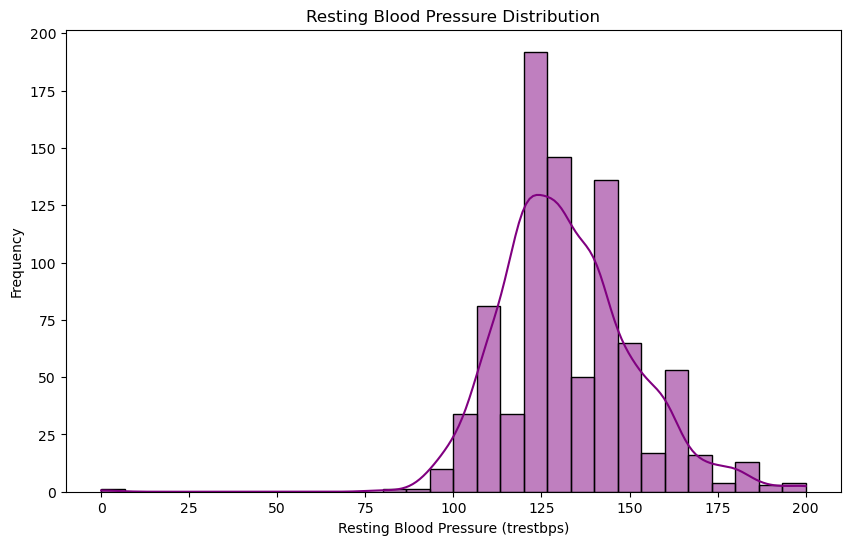

In [139]:
# create a histplot of trestbps column
plt.figure(figsize=(10,6))
sns.histplot(data['trestbps'], bins=30, kde=True, color='purple')
plt.title('Resting Blood Pressure Distribution')
plt.xlabel('Resting Blood Pressure (trestbps)')
plt.ylabel('Frequency')
plt.show()


## Dealing with missing values

In [140]:
# We are going to make a function to deal with missing values
data.isnull().sum()[data.isnull().sum() > 0].sort_values(ascending=False)
missing_data_cols = data.isnull().sum()[data.isnull().sum() > 0].index.tolist()
missing_data_cols


['trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalch',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal']

In [141]:
categorical_cols = ['thal', 'ca', 'slope', 'exang', 'restecg','fbs', 'cp', 'sex', 'num' ]
bool_cols = ['fbs', 'exang']
numeric_cols = ['oldpeak', 'thalch', 'chol', 'trestbps', 'age']

In [142]:
# define the function to impute the missing values in categorical columns
def impute_categorical_missing_values(passed_col):
    data_null = data[data[passed_col].isnull()]       # FIXED
    data_not_null = data[data[passed_col].notnull()]

    X = data_not_null.drop(passed_col, axis=1)
    y = data_not_null[passed_col]

    other_missing_cols = [col for col in missing_data_cols if col != passed_col]

    label_encoder = LabelEncoder()
    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    if passed_col in bool_cols:
        y = label_encoder.fit_transform(y)

    iterative_imputer = IterativeImputer(
        estimator=RandomForestClassifier(random_state=42),
        add_indicator=True
    )

    # Impute other missing columns
    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_vals = X[col].values.reshape(-1, 1)
            imputed_vals = iterative_imputer.fit_transform(col_vals)
            X[col] = imputed_vals[:, 0]

    # Train classifier
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    rf_classifier = RandomForestClassifier(random_state=42)
    rf_classifier.fit(X_train, y_train)
    y_pred = rf_classifier.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"The feature '{passed_col}' has been imputed with {round(acc * 100, 2)}% accuracy\n")

    # Predict missing rows
    X_null = data_null.drop(passed_col, axis=1)

    for col in X_null.columns:
        if X_null[col].dtype == 'object' or X_null[col].dtype == 'category':
            X_null[col] = label_encoder.fit_transform(X_null[col])

    for col in other_missing_cols:
        if X_null[col].isnull().sum() > 0:
            col_vals = X_null[col].values.reshape(-1, 1)
            imputed_vals = iterative_imputer.fit_transform(col_vals)
            X_null[col] = imputed_vals[:, 0]

    if len(data_null) > 0:
        data_null[passed_col] = rf_classifier.predict(X_null)
        if passed_col in bool_cols:
            data_null[passed_col] = data_null[passed_col].map({0: False, 1: True})

    data_combined = pd.concat([data_not_null, data_null])
    return data_combined[passed_col]


# define the function to impute the missing values in numeric columns
def impute_numerical_missing_values(passed_col):
    data_null = data[data[passed_col].isnull()]       # FIXED
    data_not_null = data[data[passed_col].notnull()]

    X = data_not_null.drop(passed_col, axis=1)
    y = data_not_null[passed_col]

    other_missing_cols = [col for col in missing_data_cols if col != passed_col]

    label_encoder = LabelEncoder()
    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    iterative_imputer = IterativeImputer(
        estimator=RandomForestRegressor(random_state=42),
        add_indicator=True
    )

    # Impute other missing columns
    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_vals = X[col].values.reshape(-1, 1)
            imputed_vals = iterative_imputer.fit_transform(col_vals)
            X[col] = imputed_vals[:, 0]

    # Train regressor
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    rf_regressor = RandomForestRegressor(random_state=42)
    rf_regressor.fit(X_train, y_train)
    y_pred = rf_regressor.predict(X_test)
    r2score = r2_score(y_test, y_pred)

    print(f"The feature '{passed_col}' has been imputed with R2 score of {round(r2score * 100, 2)}\n")

    # Predict missing rows
    X_null = data_null.drop(passed_col, axis=1)

    for col in X_null.columns:
        if X_null[col].dtype == 'object' or X_null[col].dtype == 'category':
            X_null[col] = label_encoder.fit_transform(X_null[col])

    for col in other_missing_cols:
        if X_null[col].isnull().sum() > 0:
            col_vals = X_null[col].values.reshape(-1, 1)
            imputed_vals = iterative_imputer.fit_transform(col_vals)
            X_null[col] = imputed_vals[:, 0]

    if len(data_null) > 0:
        data_null[passed_col] = rf_regressor.predict(X_null)

    data_combined = pd.concat([data_not_null, data_null])
    return data_combined[passed_col]





In [143]:
import warnings
warnings.filterwarnings('ignore')

for col in missing_data_cols:

    # Print missing percentage (your required format)
    missing_percent = round((data[col].isnull().mean() * 100), 2)
    print(f"Missing Values {col} : {missing_percent}%")

    # Imputation
    if col in categorical_cols:
        data[col] = impute_categorical_missing_values(col)

    elif col in numeric_cols:
        data[col] = impute_numerical_missing_values(col)
 


Missing Values trestbps : 6.41%
The feature 'trestbps' has been imputed with R2 score of 5.52

Missing Values chol : 3.26%
The feature 'chol' has been imputed with R2 score of 66.7

Missing Values fbs : 9.78%
The feature 'fbs' has been imputed with 80.72% accuracy

Missing Values restecg : 0.22%
The feature 'restecg' has been imputed with 63.04% accuracy

Missing Values thalch : 5.98%
The feature 'thalch' has been imputed with R2 score of 31.93

Missing Values exang : 5.98%
The feature 'exang' has been imputed with 79.19% accuracy

Missing Values oldpeak : 6.74%
The feature 'oldpeak' has been imputed with R2 score of 39.58

Missing Values slope : 33.59%
The feature 'slope' has been imputed with 70.73% accuracy

Missing Values ca : 66.41%
The feature 'ca' has been imputed with 67.74% accuracy

Missing Values thal : 52.83%
The feature 'thal' has been imputed with 70.11% accuracy



In [144]:
# # check if there is any missing value left
data.isnull().sum()

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

### Dealing with outliers


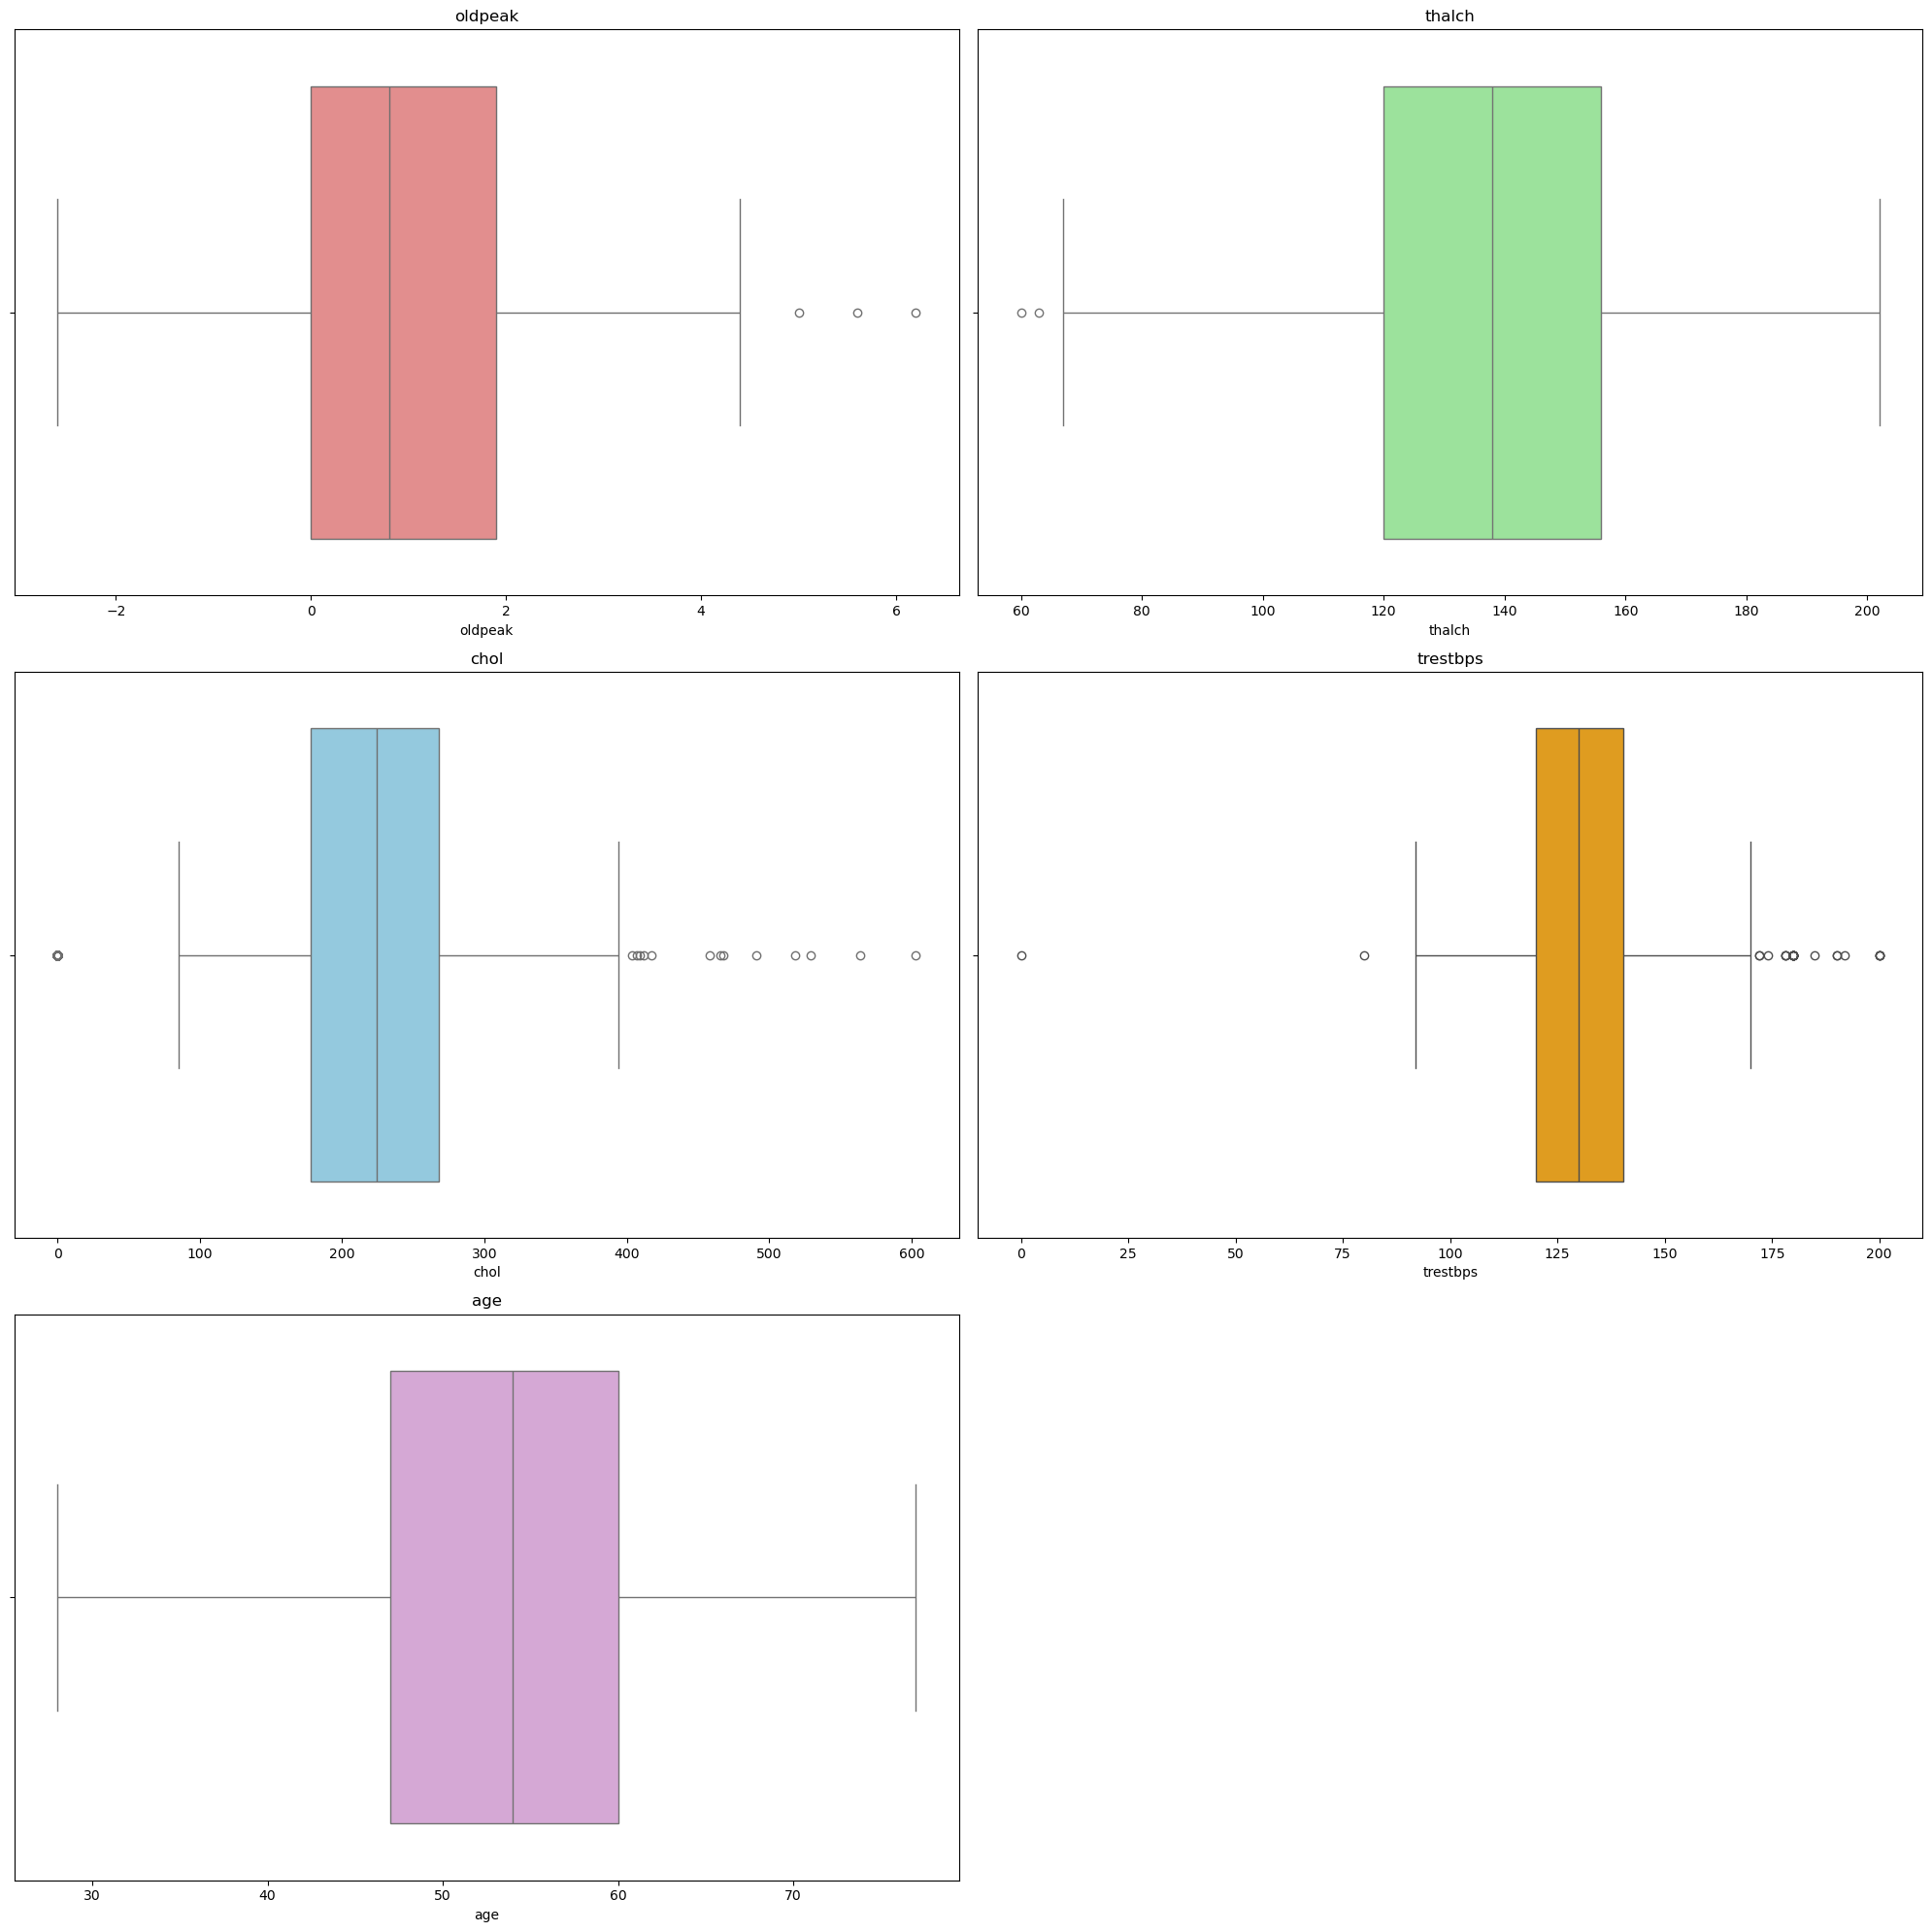

In [149]:
 
plt.figure(figsize=(20, 20))

# use valid color names
colors = ['lightcoral', 'lightgreen', 'skyblue', 'orange', 'plum']

for i, col in enumerate(numeric_cols):
    plt.subplot(3, 2, i + 1)
    
    # safe color assignment (cycles colors if columns > colors)
    sns.boxplot(data=data, x=col, color=colors[i % len(colors)])
    
    plt.title(col)

plt.tight_layout()
plt.show()


In [150]:
# make box plots of all the numeric columns using for loop and plotly
fig = px.box(data_frame=data, y='age')
fig.show()

fig = px.box(data_frame=data, y='trestbps')
fig.show()

fig = px.box(data_frame=data, y='chol')
fig.show()

fig = px.box(data_frame=data, y='thalch')
fig.show()

fig = px.box(data_frame=data, y='oldpeak')
fig.show()

In [151]:
# print the row from data where trestbps value is 0
data[data['trestbps'] == 0]


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
753,754,55,Male,VA Long Beach,non-anginal,0.0,0.0,False,normal,155.0,False,1.5,flat,2.0,reversable defect,3


In [152]:
# remove this row from data
data = data[data['trestbps'] != 0]

## Machine learning

In [153]:
data['num'].value_counts()

num
0    411
1    265
2    109
3    106
4     28
Name: count, dtype: int64

The Target Column is num which is the predicted attribute. We will use this column to predict the heart disease. The unique values in this column are: [0, 1, 2, 3, 4], which states that there are 5 types of heart diseases.

1. 0 = no heart disease
2. 1 = mild heart disease
3. 2 = moderate heart disease 
4. 3 = severe heart disease
5. 4 = critical heart disease 

In [154]:
# split the data into X and y
X = data.drop('num', axis=1)
y = data['num']

label_encoder = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object' or X[col].dtype == 'category':
        X[col] = label_encoder.fit_transform(X[col])
    else:
        pass
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [157]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
import joblib

models = [
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('Gradient Boosting', GradientBoostingClassifier(random_state=42)),
    ('Support Vector Machine', SVC(random_state=42)),
    ('Logistic Regression', LogisticRegression(random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Ada Boost', AdaBoostClassifier(random_state=42)),
    ('XG Boost', XGBClassifier(random_state=42)),
    ('Naive Bayes', GaussianNB())
]

best_model = None
best_accuracy = 0.0

print("Evaluating Models...\n")

for name, model in models:
    
    pipeline = Pipeline([
        ('model', model)
    ])
    
    # cross-validation
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')

    # train
    pipeline.fit(X_train, y_train)

    # test
    y_pred = pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    # print individual model results
    print(f"Model: {name}")
    print("Cross-validation Accuracy: %.2f%% (+/- %.2f%%)" % (scores.mean() * 100, scores.std() * 100))
    print("Test Accuracy: %.2f%%" % (accuracy * 100))
    print("-" * 50)

    # check best model
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = pipeline

# best model summary
print("\nBest Model:", best_model.named_steps['model'].__class__.__name__)
print("Best Model Accuracy: %.2f%%" % (best_accuracy * 100))

# save the best model
import pickle
pickle.dump(best_model, open('heart_disease_model.pkl', 'wb'))


Evaluating Models...

Model: Random Forest
Cross-validation Accuracy: 65.63% (+/- 4.48%)
Test Accuracy: 66.30%
--------------------------------------------------
Model: Gradient Boosting
Cross-validation Accuracy: 65.48% (+/- 1.90%)
Test Accuracy: 68.12%
--------------------------------------------------
Model: Support Vector Machine
Cross-validation Accuracy: 57.70% (+/- 1.52%)
Test Accuracy: 58.70%
--------------------------------------------------
Model: Logistic Regression
Cross-validation Accuracy: 50.85% (+/- 2.40%)
Test Accuracy: 50.72%
--------------------------------------------------
Model: K-Nearest Neighbors
Cross-validation Accuracy: 57.54% (+/- 3.21%)
Test Accuracy: 59.78%
--------------------------------------------------
Model: Decision Tree
Cross-validation Accuracy: 60.34% (+/- 3.03%)
Test Accuracy: 63.77%
--------------------------------------------------
Model: Ada Boost
Cross-validation Accuracy: 62.83% (+/- 4.23%)
Test Accuracy: 63.41%
----------------------------